<a href="https://colab.research.google.com/github/Sachinkmr101/COMPARATIVE-ANALYSIS-OF-TRANSFER-LEARNING-MODELS-FOR-MEDICAL-IMAGE-CLASSIFICATION/blob/main/MRI_Image_Classification_Dissertation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Comparative Analysis of Transfer Learning Models for MRI Image Classification
### Dissertation — Implementation
**Models:** VGG16 | ResNet50 | DenseNet121  
**Dataset:** Brain Tumor MRI (Kaggle)  
**Metrics:** Accuracy, Precision, Recall, F1-Score, AUC-ROC

---
> **How to use:** Runtime → Change runtime type → T4 GPU → Run All

## ✅ Step 1 — Install Dependencies & Setup

In [ ]:
# Install required libraries
!pip install -q kaggle matplotlib seaborn scikit-learn tensorflow

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, accuracy_score,
    precision_score, recall_score, f1_score
)

# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU available      : {tf.config.list_physical_devices("GPU")}')
print('✅ All libraries loaded successfully!')

TensorFlow version : 2.20.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ All libraries loaded successfully!


## ✅ Step 2 — Download Dataset from Kaggle

> **Setup Kaggle API (one-time):**
> 1. Go to https://www.kaggle.com → Account → Create New Token
> 2. Download `kaggle.json`
> 3. Upload it below when prompted

In [ ]:
from google.colab import files

# Upload kaggle.json
print('Please upload your kaggle.json file:')
uploaded = files.upload()

# Setup Kaggle credentials
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
os.rename('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

# Download Brain Tumor MRI Dataset (3264 images, 4 classes)
print('\nDownloading Brain Tumor MRI Dataset...')
!kaggle datasets download -d sartajbhuvaji/brain-tumor-classification-mri --unzip -p /content/dataset

print('\n✅ Dataset downloaded!')
!find /content/dataset -type d | head -20

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json

Dataset URL: https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri
License(s): MIT
100% 86.8M/86.8M [00:00<00:00, 330MB/s]


✅ Dataset downloaded!
/content/dataset
/content/dataset/Testing
/content/dataset/Testing/pituitary_tumor
/content/dataset/Testing/glioma_tumor
/content/dataset/Testing/meningioma_tumor
/content/dataset/Testing/no_tumor
/content/dataset/Training
/content/dataset/Training/pituitary_tumor
/content/dataset/Training/glioma_tumor
/content/dataset/Training/meningioma_tumor
/content/dataset/Training/no_tumor


## ✅ Step 3 — Configuration & Hyperparameters

In [ ]:
# ─── CONFIGURATION ───────────────────────────────────────────────────────────
# Paths — adjust if your dataset folder structure is different
TRAIN_DIR  = '/content/dataset/Training'
TEST_DIR   = '/content/dataset/Testing'

# Hyperparameters (matches dissertation Chapter 3 methodology)
IMG_SIZE    = (224, 224)       # All 3 models use 224x224
BATCH_SIZE  = 32
EPOCHS      = 50
LR          = 1e-4             # Adam learning rate
PATIENCE    = 10               # Early stopping patience
DROPOUT     = 0.5
NUM_CLASSES = 4                # glioma, meningioma, no_tumor, pituitary

CLASS_NAMES = ['glioma', 'meningioma', 'no_tumor', 'pituitary']

print('Configuration:')
print(f'  Image size   : {IMG_SIZE}')
print(f'  Batch size   : {BATCH_SIZE}')
print(f'  Max epochs   : {EPOCHS}')
print(f'  Learning rate: {LR}')
print(f'  Early stop   : patience={PATIENCE}')
print(f'  Classes      : {CLASS_NAMES}')

Configuration:
  Image size   : (224, 224)
  Batch size   : 32
  Max epochs   : 50
  Learning rate: 0.0001
  Early stop   : patience=10
  Classes      : ['glioma', 'meningioma', 'no_tumor', 'pituitary']


## ✅ Step 4 — Data Preprocessing & Augmentation

In [ ]:
# Training augmentation (matches dissertation Section 3.4.2)
train_datagen = ImageDataGenerator(
    rescale           = 1./255,
    rotation_range    = 20,
    width_shift_range = 0.1,
    height_shift_range= 0.1,
    shear_range       = 0.15,
    zoom_range        = 0.2,
    horizontal_flip   = True,
    fill_mode         = 'nearest',
    validation_split  = 0.2    # 80% train, 20% val from Training folder
)

# Test / Validation — only rescale, no augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

# Generators
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='training', seed=42, shuffle=True
)
val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical',
    subset='validation', seed=42, shuffle=False
)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=False
)

print(f'\nTrain samples      : {train_gen.samples}')
print(f'Validation samples : {val_gen.samples}')
print(f'Test samples       : {test_gen.samples}')
print(f'Class indices      : {train_gen.class_indices}')

Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.
Found 394 images belonging to 4 classes.

Train samples      : 2297
Validation samples : 573
Test samples       : 394
Class indices      : {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


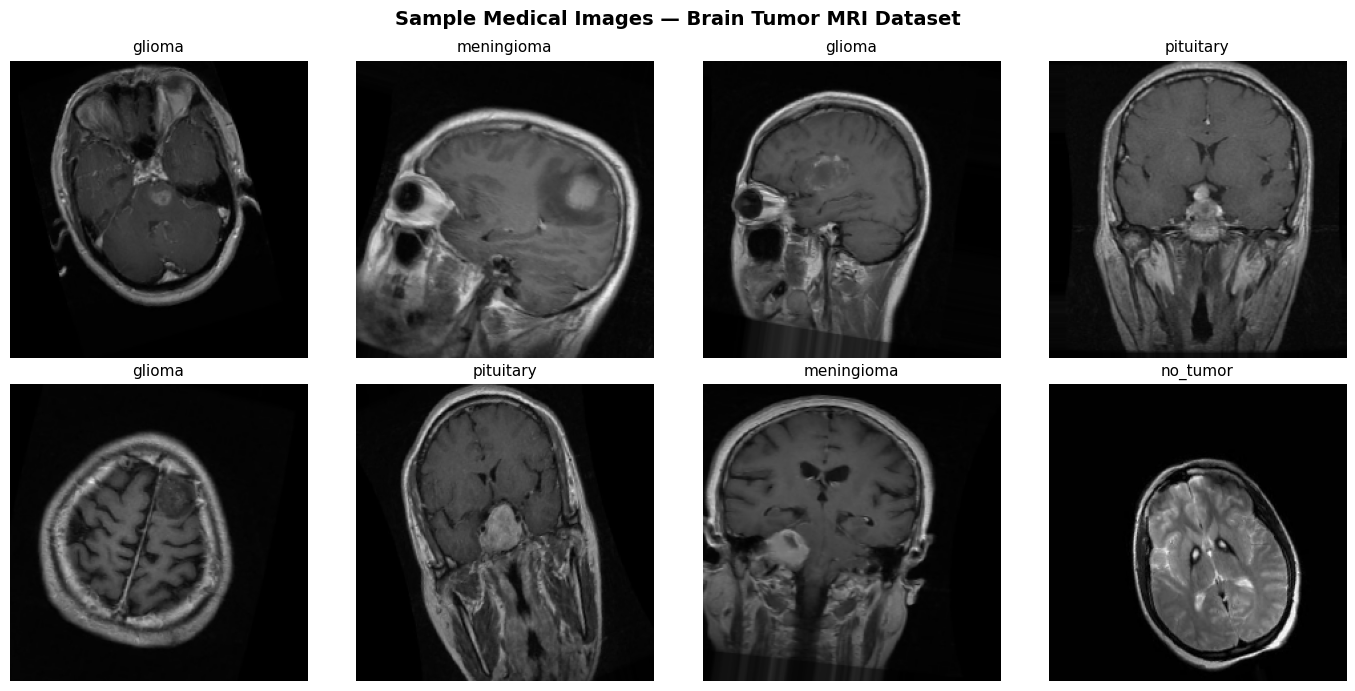

✅ Sample images visualised


In [ ]:
# Visualise sample images from each class
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Sample Medical Images — Brain Tumor MRI Dataset', fontsize=14, fontweight='bold')

imgs, labels = next(train_gen)
for i, ax in enumerate(axes.flat):
    if i < len(imgs):
        ax.imshow(imgs[i])
        ax.set_title(CLASS_NAMES[np.argmax(labels[i])], fontsize=11)
        ax.axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sample images visualised')

## ✅ Step 5 — Build Transfer Learning Models
### Fine-tuning strategy: freeze base → train classifier → unfreeze top block → fine-tune

In [ ]:
def build_model(base_name, num_classes=4, dropout=0.5, lr=1e-4):
    """
    Build a transfer learning model using fine-tuning strategy.
    Phase 1: Only classifier head is trained.
    Phase 2: Top convolutional block + head fine-tuned (low lr).
    Returns model ready for Phase 1 training.
    """
    input_shape = (224, 224, 3)

    if base_name == 'VGG16':
        base = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
        unfreeze_from = 'block5_conv1'   # Last conv block for fine-tuning
    elif base_name == 'ResNet50':
        base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
        unfreeze_from = 'conv5_block1_0_conv'
    elif base_name == 'DenseNet121':
        base = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)
        unfreeze_from = 'conv5_block1_0_conv'
    else:
        raise ValueError(f'Unknown model: {base_name}')

    # Phase 1: Freeze entire base
    base.trainable = False

    # Classifier head
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(dropout * 0.5)(x)
    output = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=output)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model, base, unfreeze_from


def unfreeze_top_block(model, base, unfreeze_from, lr=1e-5):
    """Phase 2: Unfreeze top convolutional block for fine-tuning."""
    base.trainable = True
    found = False
    for layer in base.layers:
        if layer.name == unfreeze_from:
            found = True
        layer.trainable = found

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    trainable = sum(1 for l in model.layers if l.trainable)
    print(f'  Unfrozen from: {unfreeze_from} | Trainable layers: {trainable}')
    return model


print('✅ Model builder functions defined')

✅ Model builder functions defined


## ✅ Step 6 — Training Loop (All 3 Models)

In [ ]:
def train_model(model_name):
    print(f'\n{"="*60}')
    print(f'  Training: {model_name}')
    print(f'{"="*60}')

    model, base, unfreeze_from = build_model(model_name, NUM_CLASSES, DROPOUT, LR)
    print(f'Total params: {model.count_params():,}')

    # Callbacks
    callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=PATIENCE,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-7, verbose=1),
        ModelCheckpoint(f'{model_name}_best.h5', monitor='val_accuracy',
                        save_best_only=True, verbose=0)
    ]

    # ── Phase 1: Train classifier head only ──
    print('\nPhase 1: Training classifier head (base frozen)...')
    hist1 = model.fit(
        train_gen, validation_data=val_gen,
        epochs=20, callbacks=callbacks, verbose=1
    )

    # ── Phase 2: Fine-tune top convolutional block ──
    print('\nPhase 2: Fine-tuning top convolutional block...')
    model = unfreeze_top_block(model, base, unfreeze_from, lr=LR/10)

    callbacks_ft = [
        EarlyStopping(monitor='val_accuracy', patience=PATIENCE,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-8, verbose=1),
        ModelCheckpoint(f'{model_name}_finetuned.h5', monitor='val_accuracy',
                        save_best_only=True, verbose=0)
    ]
    hist2 = model.fit(
        train_gen, validation_data=val_gen,
        epochs=EPOCHS, callbacks=callbacks_ft, verbose=1
    )

    # Merge histories
    history = {}
    for k in hist1.history:
        history[k] = hist1.history[k] + hist2.history[k]

    return model, history


# Train all three models
models_trained  = {}
histories       = {}

for name in ['VGG16', 'ResNet50', 'DenseNet121']:
    model, history = train_model(name)
    models_trained[name]  = model
    histories[name]       = history

print('\n✅ All models trained successfully!')


  Training: VGG16
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params: 15,111,748

Phase 1: Training classifier head (base frozen)...
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.3569 - loss: 1.4691

72/72 ━━━━━━━━━━━━━━━━━━━━ 89s 923ms/step - accuracy: 0.4423 - loss: 1.2745 - val_accuracy: 0.4572 - val_loss: 1.2732 - learning_rate: 1.0000e-04
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.5900 - loss: 0.9747

72/72 ━━━━━━━━━━━━━━━━━━━━ 45s 616ms/step - accuracy: 0.6252 - loss: 0.9210 - val_accuracy: 0.5044 - val_loss: 1.1867 - learning_rate: 1.0000e-04
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.6750 - loss: 0.7989

72/72 ━━━━━━━━━━━━━━━━━━━━ 45s 620ms/step - accuracy: 0.6926 - loss: 0.7817 - val_accuracy: 0.5864 - val_loss: 1.0938 - learning_rate: 1.0000e-04
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.7274 - loss: 0.7065

72/72 ━━━━━━━━━━━━━━━━━━━━ 43s 599ms/step - accuracy: 0.7214 - loss: 0.7165 - val_accuracy: 0.6649 - val_loss: 0.9860 - learning_rate: 1.0000e-04
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.7394 - loss: 0.6877

...

72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 567ms/step - accuracy: 0.8677 - loss: 0.3477 - val_accuracy: 0.8028 - val_loss: 0.5289 - learning_rate: 1.0000e-04
Epoch 14/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 553ms/step - accuracy: 0.8742 - loss: 0.3336 - val_accuracy: 0.8028 - val_loss: 0.5142 - learning_rate: 1.0000e-04
Epoch 15/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 548ms/step - accuracy: 0.8759 - loss: 0.3432 - val_accuracy: 0.8028 - val_loss: 0.4905 - learning_rate: 1.0000e-04
Epoch 16/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 566ms/step - accuracy: 0.8907 - loss: 0.3153 - val_accuracy: 0.7976 - val_loss: 0.5502 - learning_rate: 1.0000e-04
Epoch 17/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.8942 - loss: 0.2956

72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 559ms/step - accuracy: 0.8890 - loss: 0.3044 - val_accuracy: 0.8080 - val_loss: 0.4981 - learning_rate: 1.0000e-04
Epoch 18/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 542ms/step - accuracy: 0.8877 - loss: 0.3079 - val_accuracy: 0.7976 - val_loss: 0.5141 - learning_rate: 1.0000e-04
Epoch 19/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.8958 - loss: 0.2855

72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 563ms/step - accuracy: 0.8907 - loss: 0.2909 - val_accuracy: 0.8325 - val_loss: 0.4638 - learning_rate: 1.0000e-04
Epoch 20/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 548ms/step - accuracy: 0.8890 - loss: 0.2775 - val_accuracy: 0.8185 - val_loss: 0.4832 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 19.

Phase 2: Fine-tuning top convolutional block...
  Unfrozen from: conv5_block1_0_conv | Trainable layers: 7
Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 612ms/step - accuracy: 0.8868 - loss: 0.2855

72/72 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.8920 - loss: 0.2854 - val_accuracy: 0.8290 - val_loss: 0.4922 - learning_rate: 1.0000e-05
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 556ms/step - accuracy: 0.8938 - loss: 0.2859 - val_accuracy: 0.8133 - val_loss: 0.4932 - learning_rate: 1.0000e-05
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 558ms/step - accuracy: 0.8907 - loss: 0.2752 - val_accuracy: 0.8168 - val_loss: 0.4891 - learning_rate: 1.0000e-05
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 550ms/step - accuracy: 0.8951 - loss: 0.2923 - val_accuracy: 0.8133 - val_loss: 0.5126 - learning_rate: 1.0000e-05
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 560ms/step - accuracy: 0.8968 - loss: 0.2819 - val_accuracy: 0.8133 - val_loss: 0.5233 - learning_rate: 1.0000e-05
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 549ms/step - accuracy: 0.9016 - loss: 0.2602 - val_accuracy: 0.8168 - val_loss: 0.4995 - learning_rate: 1.0000e-05
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 575ms/step - accuracy: 0.8925

72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 565ms/step - accuracy: 0.9042 - loss: 0.2613 - val_accuracy: 0.8412 - val_loss: 0.4757 - learning_rate: 1.0000e-05
Epoch 11/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 553ms/step - accuracy: 0.9042 - loss: 0.2614 - val_accuracy: 0.8237 - val_loss: 0.4976 - learning_rate: 1.0000e-05
Epoch 12/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 549ms/step - accuracy: 0.9025 - loss: 0.2782 - val_accuracy: 0.8168 - val_loss: 0.5096 - learning_rate: 1.0000e-05
Epoch 13/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 544ms/step - accuracy: 0.8977 - loss: 0.2815 - val_accuracy: 0.8202 - val_loss: 0.4742 - learning_rate: 1.0000e-05
Epoch 14/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 547ms/step - accuracy: 0.9029 - loss: 0.2625 - val_accuracy: 0.8185 - val_loss: 0.4972 - learning_rate: 1.0000e-05
Epoch 15/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 574ms/step - accuracy: 0.9025 - loss: 0.2724 - val_accuracy: 0.8290 - val_loss: 0.4912 - learning_rate: 1.0000e-05
Epoch 16/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 579ms/step - accuracy

## ✅ Step 7 — Evaluate All Models

In [ ]:
from sklearn.preprocessing import label_binarize

results = {}

for name, model in models_trained.items():
    print(f'\nEvaluating {name}...')
    test_gen.reset()

    # Predictions
    y_pred_proba = model.predict(test_gen, verbose=0)
    y_pred       = np.argmax(y_pred_proba, axis=1)
    y_true       = test_gen.classes

    # Metrics
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)

    # AUC-ROC (one-vs-rest)
    y_true_bin = label_binarize(y_true, classes=[0,1,2,3])
    auc_scores = []
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
        auc_scores.append(auc(fpr, tpr))
    mean_auc = np.mean(auc_scores)

    results[name] = {
        'accuracy'  : acc,
        'precision' : prec,
        'recall'    : rec,
        'f1'        : f1,
        'auc'       : mean_auc,
        'y_pred'    : y_pred,
        'y_true'    : y_true,
        'y_proba'   : y_pred_proba,
        'auc_scores': auc_scores
    }

    print(f'  Accuracy  : {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  AUC-ROC   : {mean_auc:.4f}')

print('\n✅ Evaluation complete!')


Evaluating VGG16...
  Accuracy  : 0.7310 (73.10%)
  Precision : 0.7939
  Recall    : 0.7180
  F1-Score  : 0.6895
  AUC-ROC   : 0.8963

Evaluating ResNet50...
  Accuracy  : 0.5254 (52.54%)
  Precision : 0.6094
  Recall    : 0.5193
  F1-Score  : 0.4880
  AUC-ROC   : 0.7326

Evaluating DenseNet121...
  Accuracy  : 0.6701 (67.01%)
  Precision : 0.6957
  Recall    : 0.6542
  F1-Score  : 0.6300
  AUC-ROC   : 0.8775

✅ Evaluation complete!


## ✅ Step 8 — Results Summary Table

In [ ]:
print('\n' + '='*70)
print(f'{"Model":<15} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1-Score":>10} {"AUC-ROC":>10}')
print('='*70)

for name, r in results.items():
    print(f'{name:<15} '
          f'{r["accuracy"]*100:>9.2f}% '
          f'{r["precision"]:>10.4f} '
          f'{r["recall"]:>10.4f} '
          f'{r["f1"]:>10.4f} '
          f'{r["auc"]:>10.4f}')

print('='*70)

best = max(results, key=lambda k: results[k]['accuracy'])
print(f'\nBest model: {best} (Accuracy: {results[best]["accuracy"]*100:.2f}%)')

## ✅ Step 9 — Training & Validation Curves

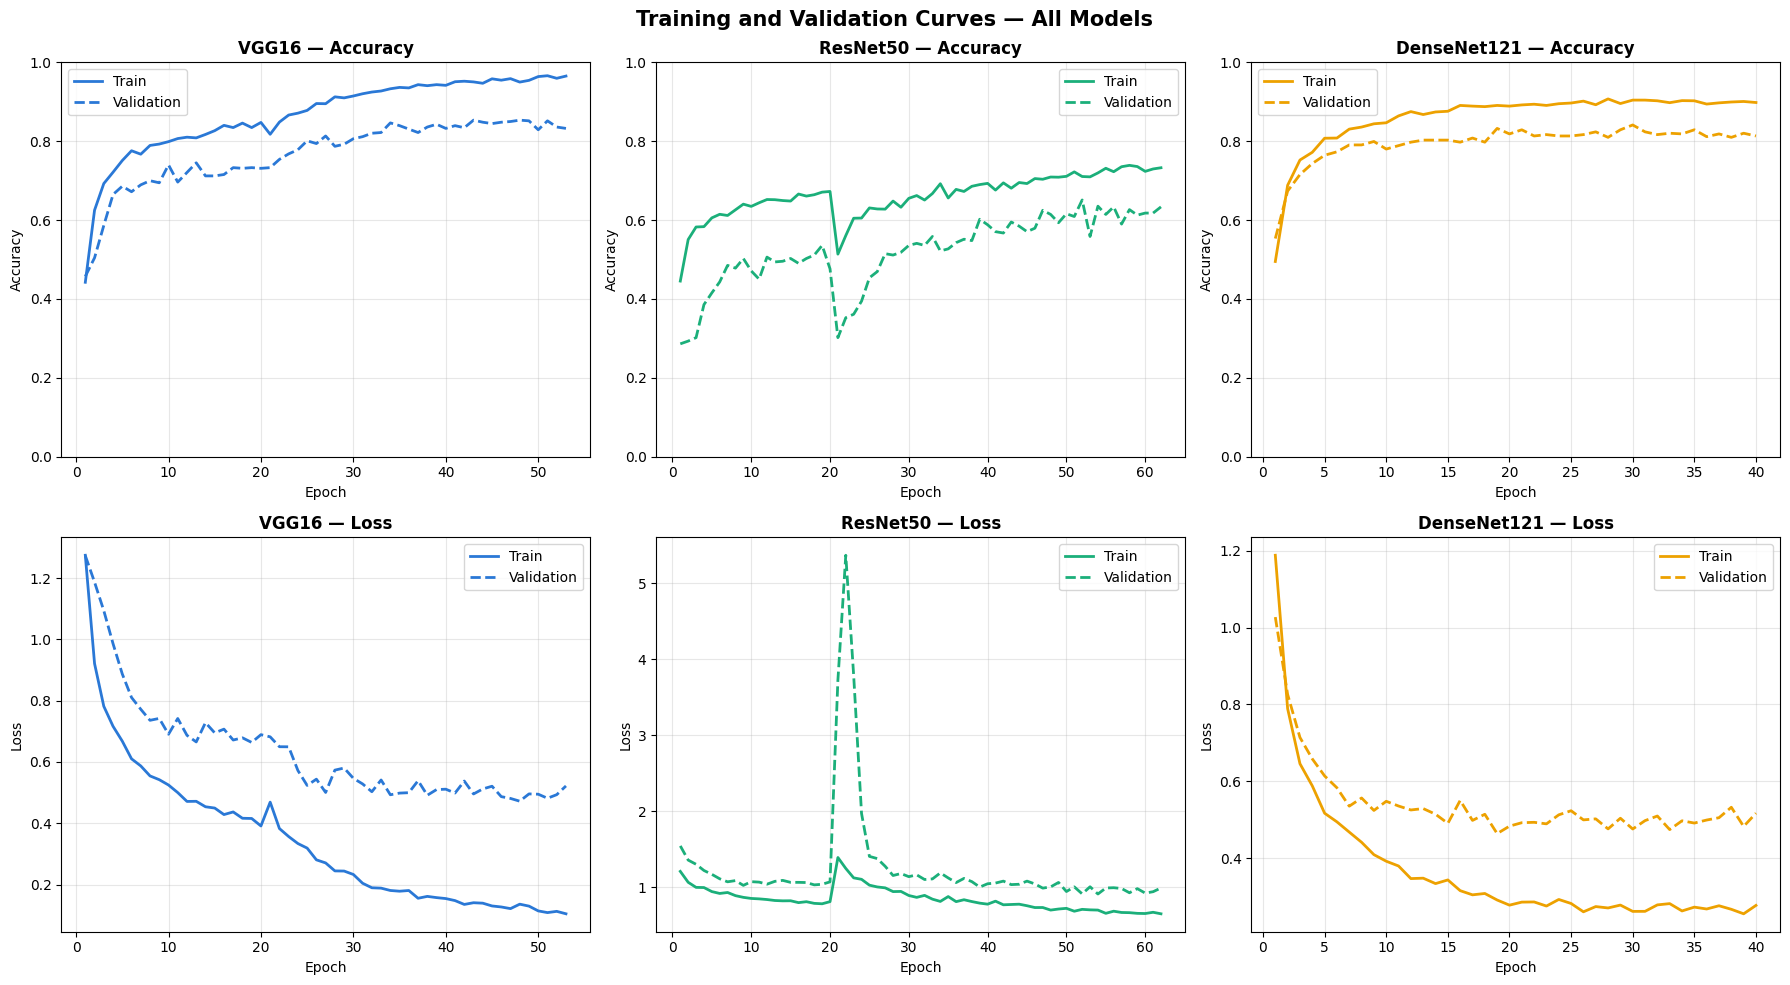

✅ Training curves saved


In [ ]:
colors = {'VGG16': '#2a78d6', 'ResNet50': '#1baf7a', 'DenseNet121': '#eda100'}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training and Validation Curves — All Models', fontsize=15, fontweight='bold')

for col, (name, hist) in enumerate(histories.items()):
    color = colors[name]
    epochs_ran = range(1, len(hist['accuracy']) + 1)

    # Accuracy
    ax = axes[0, col]
    ax.plot(epochs_ran, hist['accuracy'], color=color, linewidth=2, label='Train')
    ax.plot(epochs_ran, hist['val_accuracy'], color=color, linewidth=2,
            linestyle='--', label='Validation')
    ax.set_title(f'{name} — Accuracy', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])

    # Loss
    ax = axes[1, col]
    ax.plot(epochs_ran, hist['loss'], color=color, linewidth=2, label='Train')
    ax.plot(epochs_ran, hist['val_loss'], color=color, linewidth=2,
            linestyle='--', label='Validation')
    ax.set_title(f'{name} — Loss', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Training curves saved')

## ✅ Step 10 — Confusion Matrices

1.   List item
2.   List item



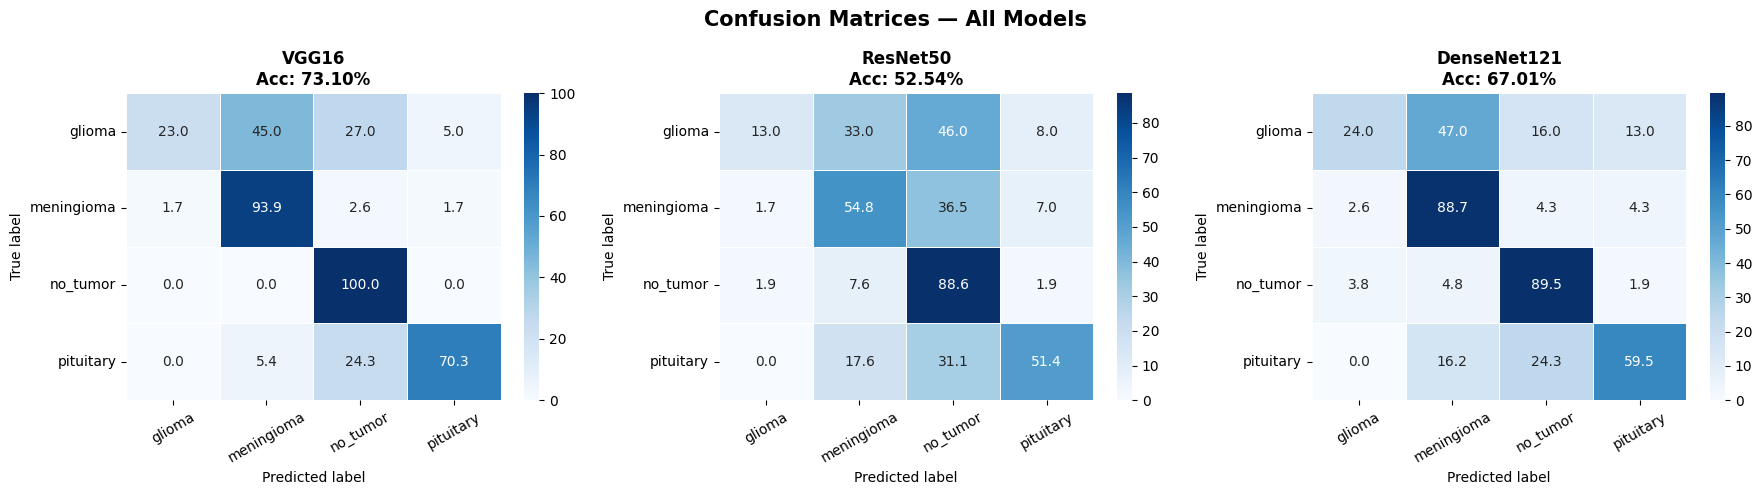

✅ Confusion matrices saved


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    sns.heatmap(
        cm_pct, annot=True, fmt='.1f', ax=ax,
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        cmap='Blues', linewidths=0.5,
        annot_kws={'size': 10}
    )
    ax.set_title(f'{name}\nAcc: {r["accuracy"]*100:.2f}%', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrices saved')

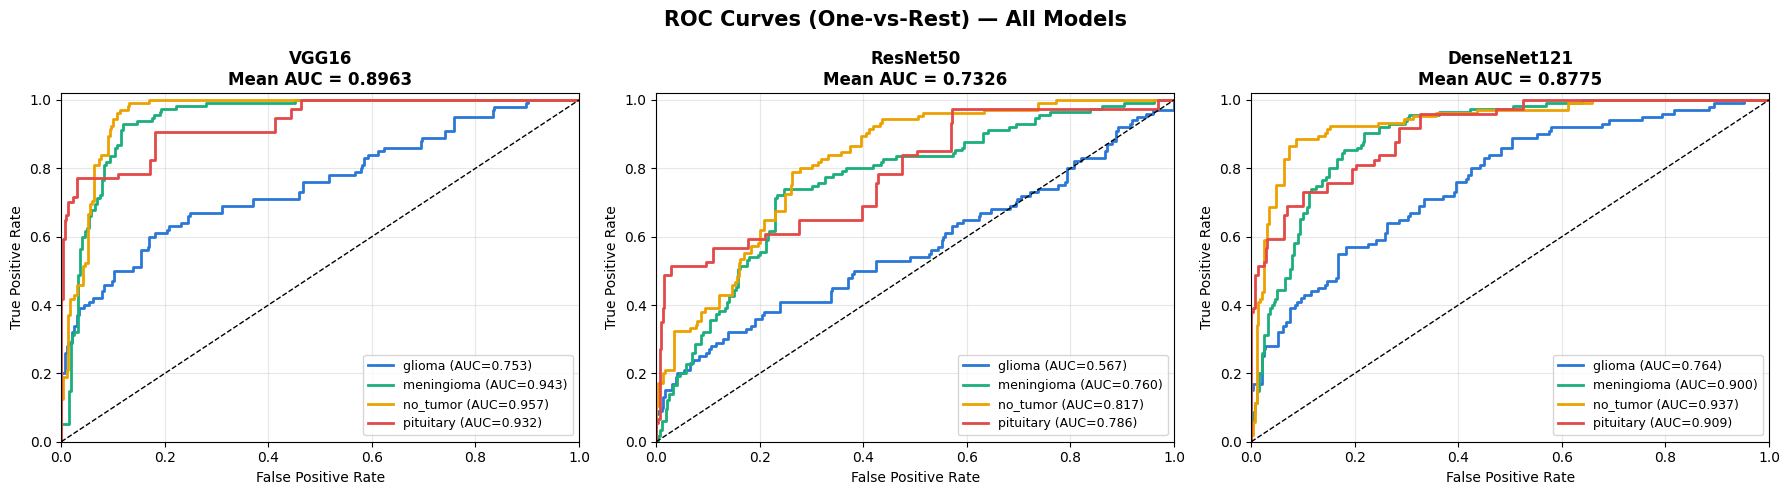

✅ ROC curves saved


In [ ]:
from sklearn.preprocessing import label_binarize

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ROC Curves (One-vs-Rest) — All Models', fontsize=15, fontweight='bold')

class_colors = ['#2a78d6', '#1baf7a', '#eda100', '#e34948']

for ax, (name, r) in zip(axes, results.items()):
    y_true_bin = label_binarize(r['y_true'], classes=[0,1,2,3])

    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], r['y_proba'][:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=class_colors[i], linewidth=2,
                label=f'{cls} (AUC={roc_auc:.3f})')

    ax.plot([0,1], [0,1], 'k--', linewidth=1)
    ax.set_title(f'{name}\nMean AUC = {r["auc"]:.4f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ ROC curves saved')

## ✅ Step 12 — Bar Chart Comparison (Dissertation Figure)

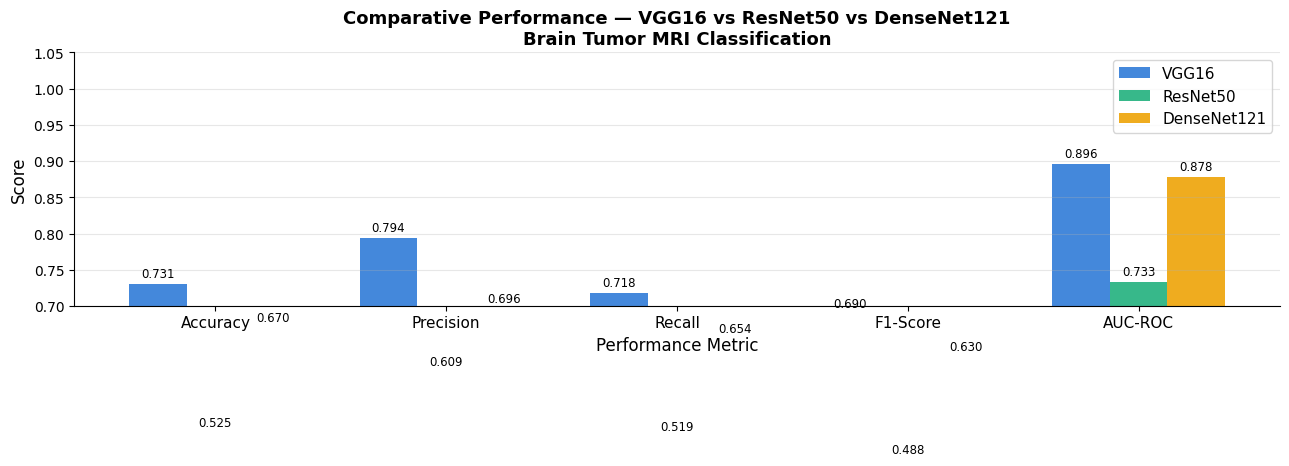

✅ Comparison bar chart saved


In [ ]:
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
model_names = list(results.keys())
bar_colors  = ['#2a78d6', '#1baf7a', '#eda100']

data = {
    name: [
        r['accuracy'], r['precision'],
        r['recall'],   r['f1'], r['auc']
    ]
    for name, r in results.items()
}

x        = np.arange(len(metrics))
bar_w    = 0.25
fig, ax  = plt.subplots(figsize=(13, 6))

for i, (name, vals) in enumerate(data.items()):
    bars = ax.bar(x + i*bar_w, vals, bar_w,
                  label=name, color=bar_colors[i], alpha=0.88)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xlabel('Performance Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparative Performance — VGG16 vs ResNet50 vs DenseNet121\nBrain Tumor MRI Classification',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + bar_w)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim([0.7, 1.05])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparison bar chart saved')

## ✅ Step 13 — Classification Report (Per-Class)

In [ ]:
for name, r in results.items():
    print(f'\n{"─"*55}')
    print(f'  Classification Report — {name}')
    print(f'{"─"*55}')
    print(classification_report(
        r['y_true'], r['y_pred'],
        target_names=CLASS_NAMES, digits=4
    ))


───────────────────────────────────────────────────────
  Classification Report — VGG16
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

      glioma     0.9200    0.2300    0.3680       100
  meningioma     0.6879    0.9391    0.7941       115
    no_tumor     0.6863    1.0000    0.8140       105
   pituitary     0.8814    0.7027    0.7820        74

    accuracy                         0.7310       394
   macro avg     0.7939    0.7180    0.6895       394
weighted avg     0.7827    0.7310    0.6890       394


───────────────────────────────────────────────────────
  Classification Report — ResNet50
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

      glioma     0.7647    0.1300    0.2222       100
  meningioma     0.5385    0.5478    0.5431       115
    no_tumor     0.4559    0.8857    0.6019       105
   pituitary     0.6786    0.5135    0.5846        74



## ✅ Step 14 — Grad-CAM Saliency Maps (Interpretability)

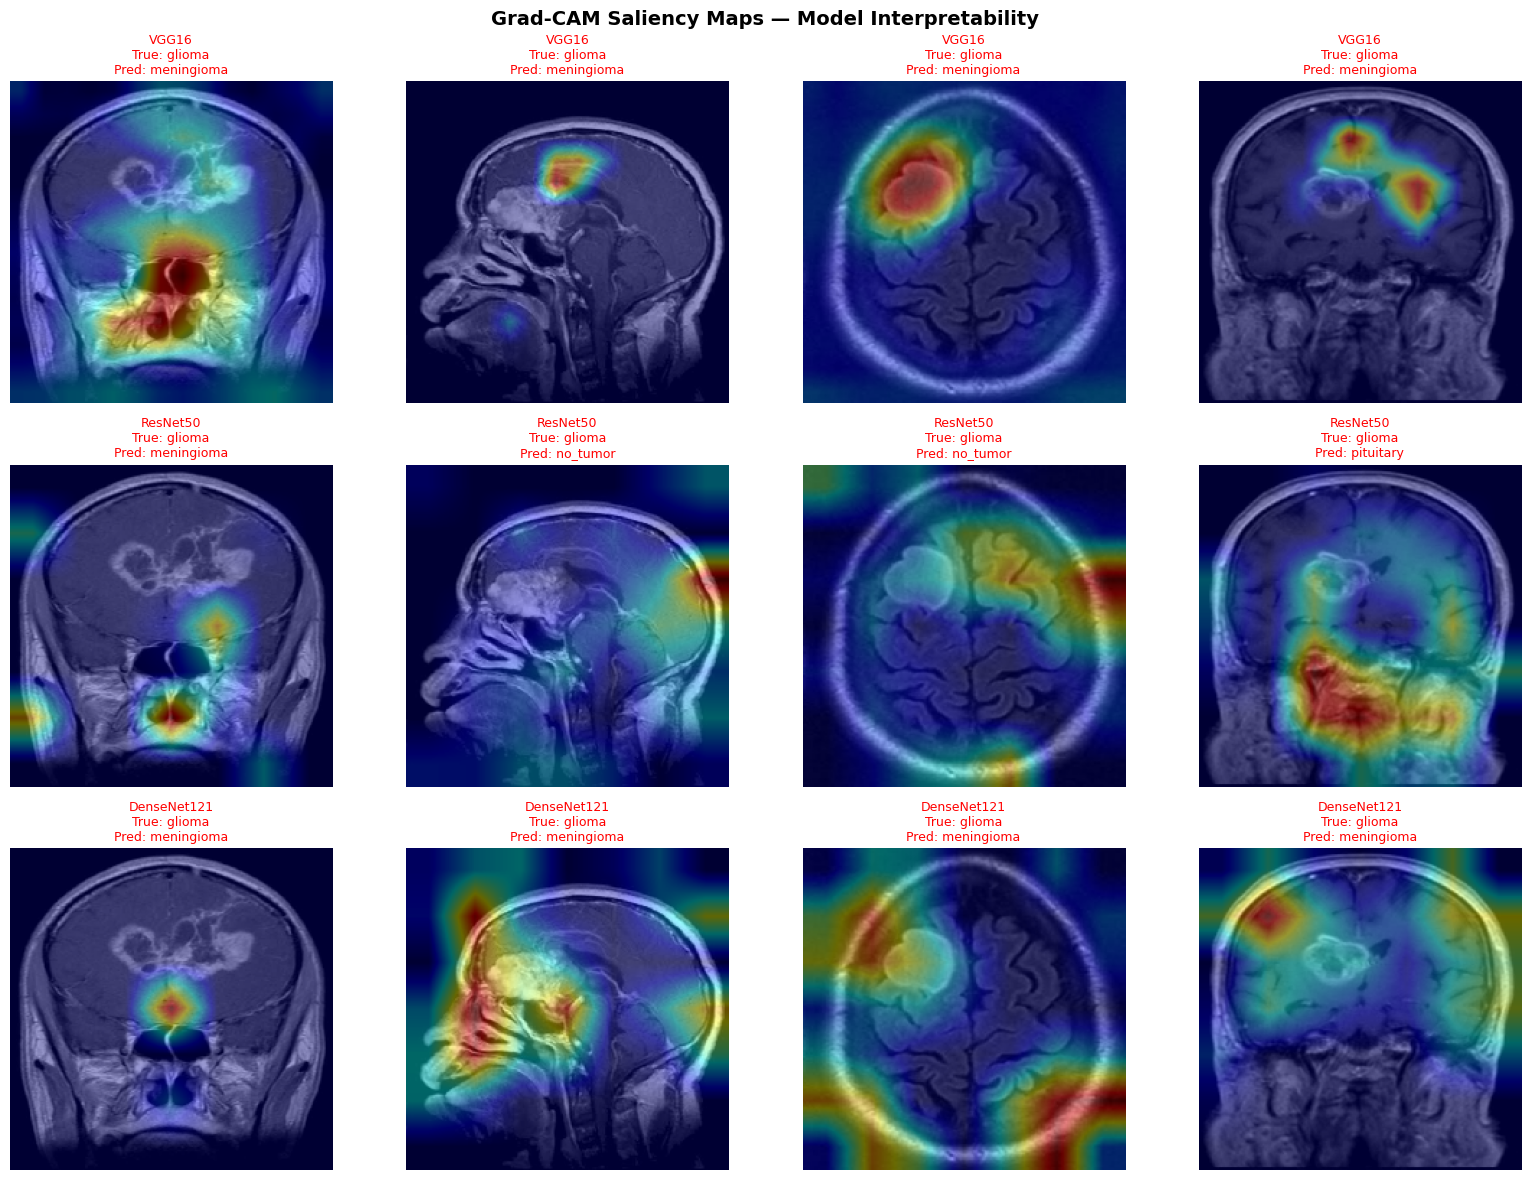

✅ Grad-CAM maps saved


In [ ]:
import cv2

def get_gradcam_layer(model_name):
    return {'VGG16': 'block5_conv3',
            'ResNet50': 'conv5_block3_out',
            'DenseNet121': 'conv5_block16_concat'}[model_name]

def make_gradcam(model, img_array, last_conv_layer):
    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads    = tape.gradient(class_channel, conv_outputs)
    pooled   = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_outputs[0]
    heatmap  = conv_out @ pooled[..., tf.newaxis]
    heatmap  = tf.squeeze(heatmap)
    heatmap  = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index)

def overlay_heatmap(img, heatmap, alpha=0.4):
    hm = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    hm = np.uint8(255 * hm)
    hm = cv2.applyColorMap(hm, cv2.COLORMAP_JET)
    hm = cv2.cvtColor(hm, cv2.COLOR_BGR2RGB)
    return np.uint8(img * 255 * (1 - alpha) + hm * alpha)

# Get 4 test images (one per class)
test_gen.reset()
imgs_batch, labels_batch = next(test_gen)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Grad-CAM Saliency Maps — Model Interpretability', fontsize=14, fontweight='bold')

for row, (name, model) in enumerate(models_trained.items()):
    try:
        last_conv = get_gradcam_layer(name)
        for col in range(4):
            img = imgs_batch[col]
            img_arr = np.expand_dims(img, axis=0)
            heatmap, pred = make_gradcam(model, img_arr, last_conv)
            overlay = overlay_heatmap(img, heatmap)
            axes[row, col].imshow(overlay)
            true_cls = CLASS_NAMES[np.argmax(labels_batch[col])]
            pred_cls = CLASS_NAMES[pred]
            color = 'green' if true_cls == pred_cls else 'red'
            axes[row, col].set_title(
                f'{name}\nTrue: {true_cls}\nPred: {pred_cls}',
                fontsize=9, color=color
            )
            axes[row, col].axis('off')
    except Exception as e:
        print(f'Grad-CAM skipped for {name}: {e}')

plt.tight_layout()
plt.savefig('gradcam_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grad-CAM maps saved')

## ✅ Step 15 — Download All Results

In [ ]:
import zipfile, json

# Save summary JSON
summary = {
    name: {
        'accuracy' : round(float(r['accuracy']), 4),
        'precision': round(float(r['precision']), 4),
        'recall'   : round(float(r['recall']), 4),
        'f1'       : round(float(r['f1']), 4),
        'auc_roc'  : round(float(r['auc']), 4)
    }
    for name, r in results.items()
}
with open('results_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

# Zip all outputs
output_files = [
    'sample_images.png', 'training_curves.png',
    'confusion_matrices.png', 'roc_curves.png',
    'model_comparison_bar.png', 'gradcam_maps.png',
    'results_summary.json'
]

with zipfile.ZipFile('dissertation_results.zip', 'w') as zf:
    for f in output_files:
        if os.path.exists(f):
            zf.write(f)
            print(f'  Added: {f}')

print('\nFinal results summary:')
print(json.dumps(summary, indent=2))

# Download
files.download('dissertation_results.zip')
print('\n✅ All results downloaded!')

  Added: sample_images.png
  Added: training_curves.png
  Added: confusion_matrices.png
  Added: roc_curves.png
  Added: model_comparison_bar.png
  Added: gradcam_maps.png
  Added: results_summary.json

Final results summary:
{
  "VGG16": {
    "accuracy": 0.731,
    "precision": 0.7939,
    "recall": 0.718,
    "f1": 0.6895,
    "auc_roc": 0.8963
  },
  "ResNet50": {
    "accuracy": 0.5254,
    "precision": 0.6094,
    "recall": 0.5193,
    "f1": 0.488,
    "auc_roc": 0.7326
  },
  "DenseNet121": {
    "accuracy": 0.6701,
    "precision": 0.6957,
    "recall": 0.6542,
    "f1": 0.63,
    "auc_roc": 0.8775
  }
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All results downloaded!
